<a href="https://colab.research.google.com/github/utkarsh-mishra19/Tensorflow_projects/blob/main/Car_price_predection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import tensorflow as tf
import pandas as pd
import seaborn as sns
from tensorflow.keras.layers import Normalization,Dense,InputLayer
from tensorflow.keras.losses import MeanSquaredError,MeanAbsoluteError
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import RootMeanSquaredError
import matplotlib.pyplot as plt


In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mayankpatel14/second-hand-used-cars-data-set-linear-regression")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'second-hand-used-cars-data-set-linear-regression' dataset.
Path to dataset files: /kaggle/input/second-hand-used-cars-data-set-linear-regression


In [7]:
data = pd.read_csv('/kaggle/input/second-hand-used-cars-data-set-linear-regression/train.csv')
data.head()

,v.id,on road old,on road now,years,km,rating,condition,economy,top speed,hp,torque,current price
0,1,535651,798186,3,78945,1,2,14,177,73,123,351318.0
1,2,591911,861056,6,117220,5,9,9,148,74,95,285001.5
2,3,686990,770762,2,132538,2,8,15,181,53,97,215386.0
3,4,573999,722381,4,101065,4,3,11,197,54,116,244295.5
4,5,691388,811335,6,61559,3,9,12,160,53,105,531114.5


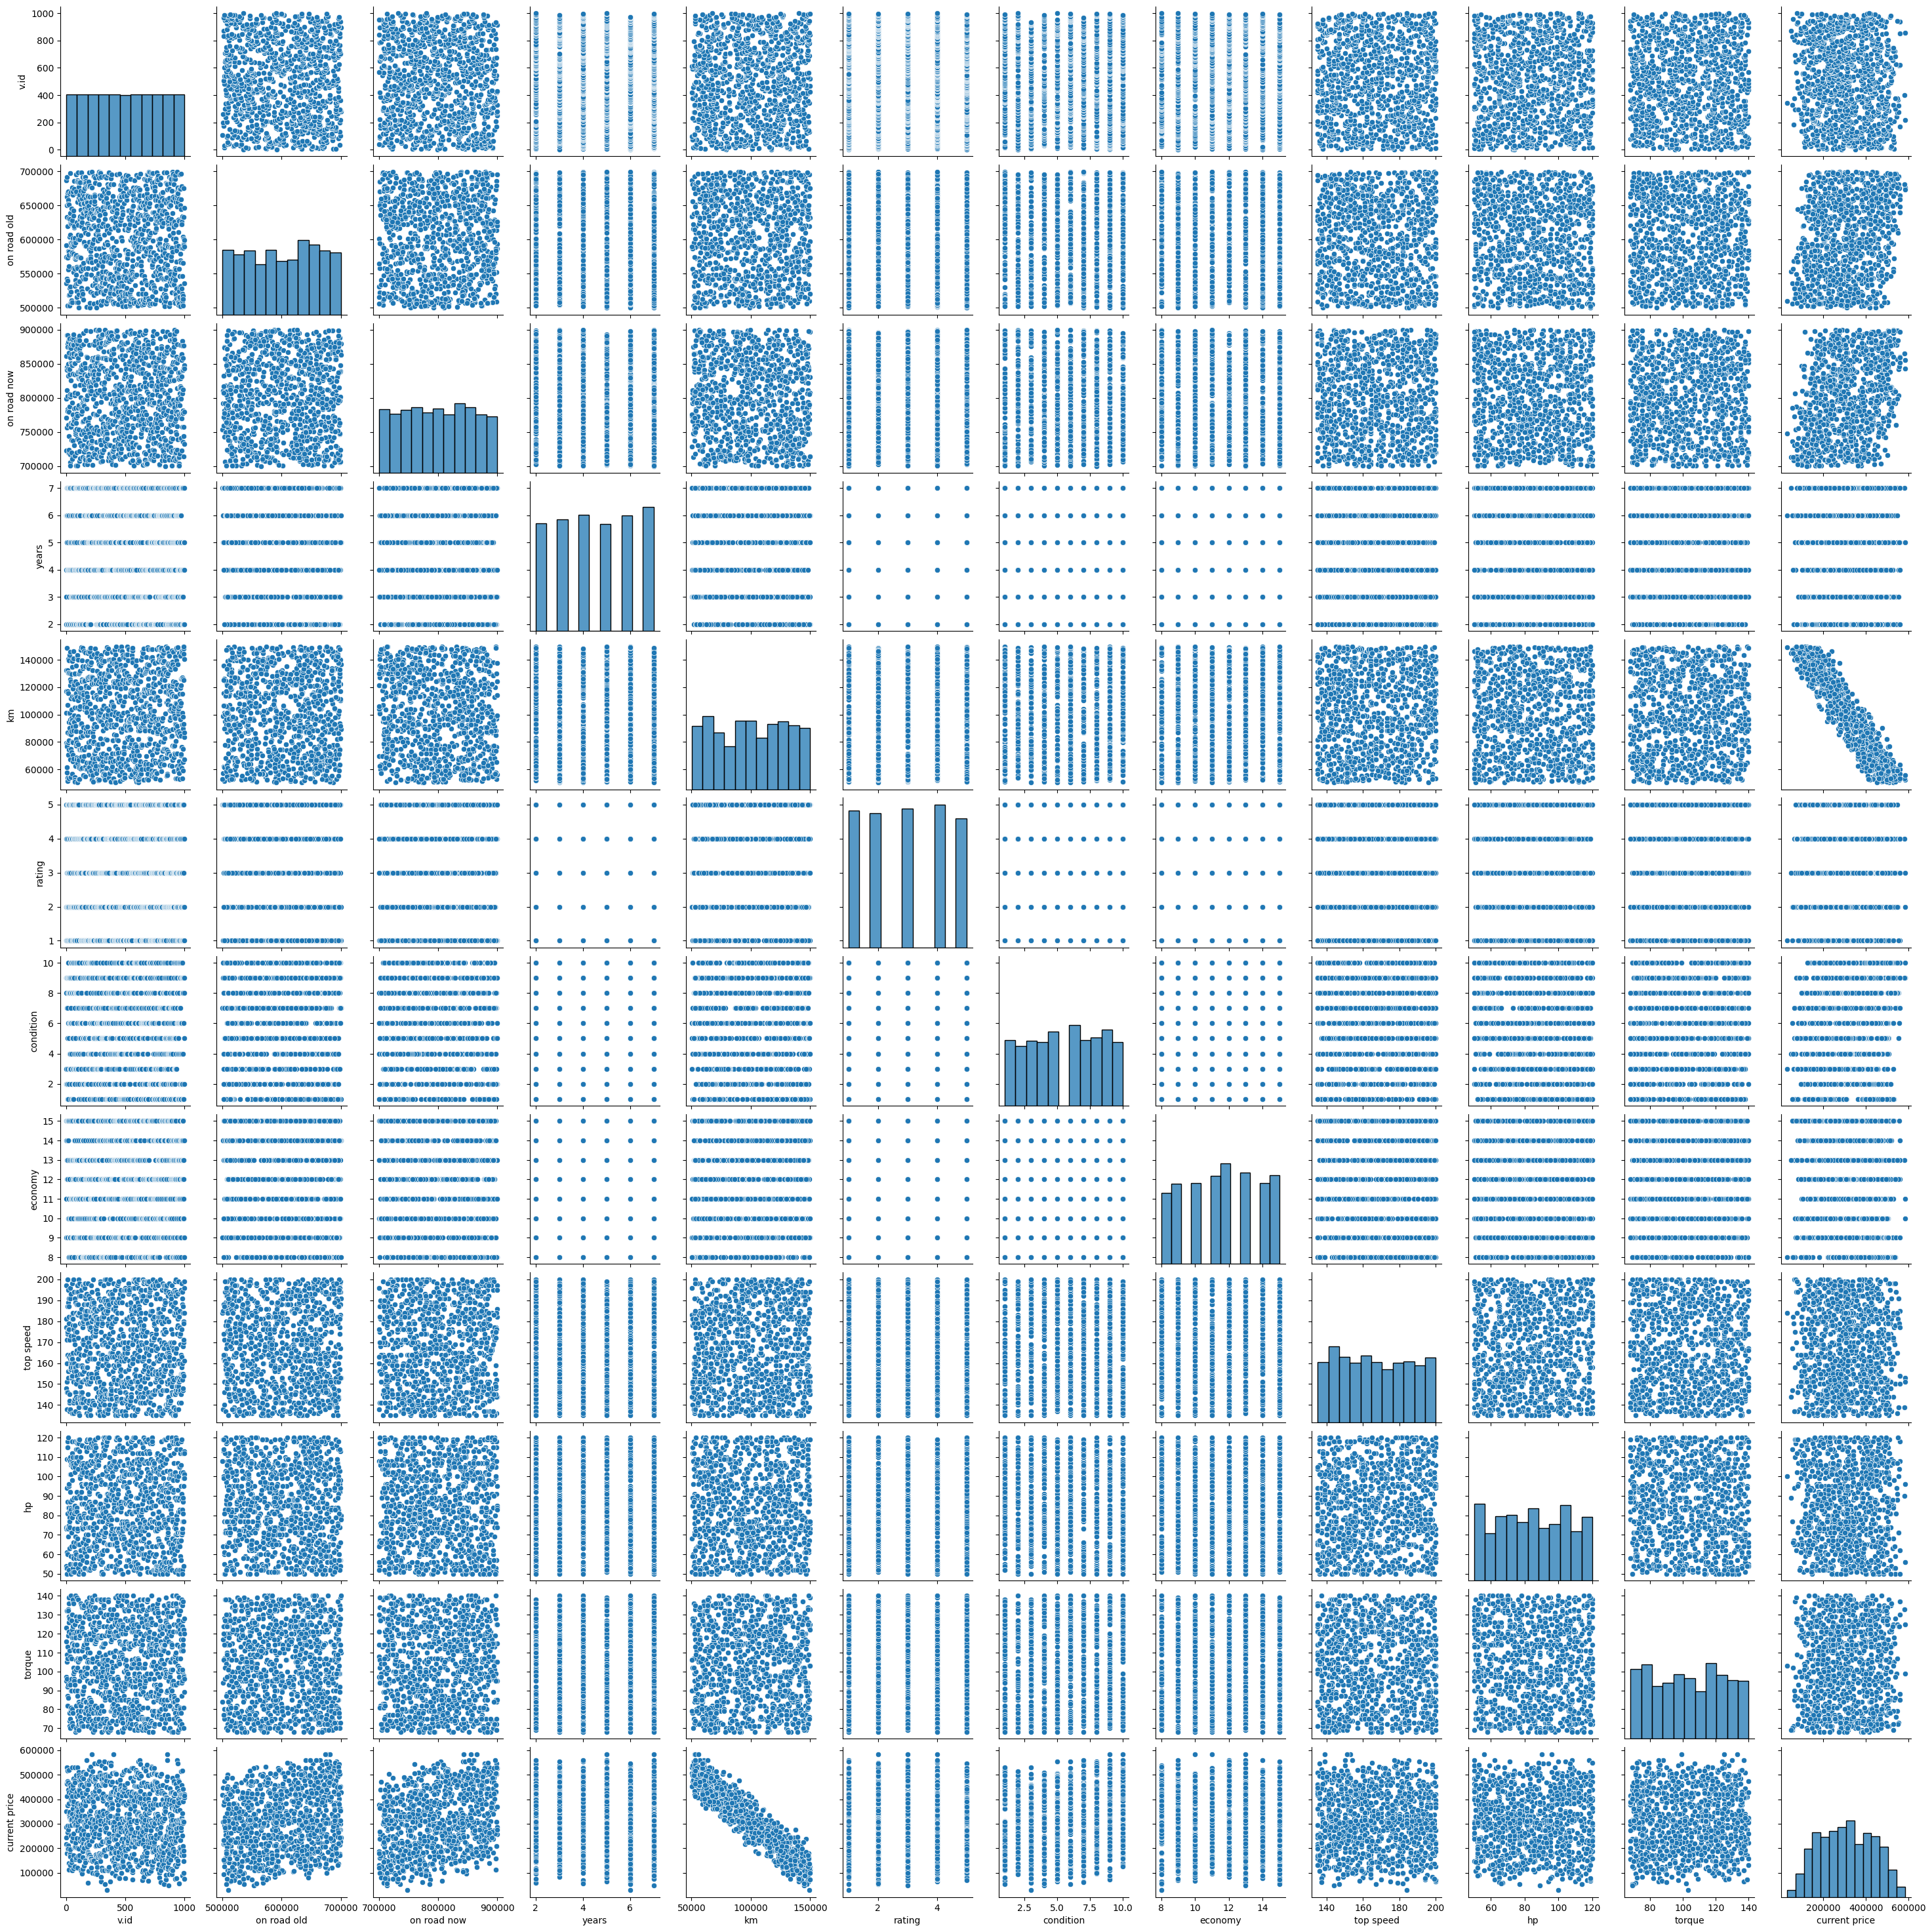

In [8]:
sns.pairplot(data[[
'v.id'  ,'on road old'  ,'on road now'  ,'years'        ,'km' ,'rating' ,'condition'    ,'economy'      ,'top speed'    ,'hp'   ,'torque' ,'current price']])

In [9]:
tensor_data = tf.constant(data)
tensor_data = tf.cast(tensor_data, tf.float32)
tensor_data = tf.random.shuffle(tensor_data)
print(tensor_data)

tf.Tensor(
[[3.800000e+02 5.438210e+05 8.384770e+05 ... 7.000000e+01 1.160000e+02
  4.216795e+05]
 [6.830000e+02 6.676290e+05 8.091880e+05 ... 5.300000e+01 8.600000e+01
  5.393770e+05]
 [7.230000e+02 5.705700e+05 8.182180e+05 ... 8.700000e+01 1.400000e+02
  3.050025e+05]
 ...
 [1.640000e+02 5.426130e+05 7.981500e+05 ... 9.600000e+01 7.800000e+01
  3.751180e+05]
 [3.400000e+02 6.610270e+05 7.291230e+05 ... 1.160000e+02 7.400000e+01
  2.249585e+05]
 [8.250000e+02 5.128090e+05 8.616150e+05 ... 5.400000e+01 8.500000e+01
  3.435950e+05]], shape=(1000, 12), dtype=float32)


In [10]:
x = tensor_data[:,3:-1]
y = tensor_data[:,-1]
y= tf.reshape(y,[-1,1])
print(x.shape)
print(y.shape)

(1000, 8)
(1000, 1)


In [11]:
x_train = x[:int(len(x)*0.6)]
y_train = y[:int(len(y)*0.6)]
x_val = x[int(len(x)*0.6):int(len(x)*0.8)]
y_val = y[int(len(y)*0.6):int(len(y)*0.8)]
x_test = x[int(len(x)*0.8):]
y_test = y[int(len(y)*0.8):]

In [12]:
normalizer = Normalization()
normalizer.adapt(x_train)
normalizer(x)

<tf.Tensor: shape=(1000, 8), dtype=float32, numpy=
array([[-1.4897624e+00, -1.0711136e+00, -7.1335685e-01, ...,
        -1.1190660e+00, -7.6779842e-01,  6.1515707e-01],
       [ 9.0503329e-01, -1.6042982e+00, -7.1335685e-01, ...,
         1.6150646e+00, -1.5933009e+00, -8.1157011e-01],
       [ 9.0503329e-01, -9.8504685e-02,  7.1098280e-01, ...,
        -6.7477316e-02,  5.7704166e-02,  1.7565389e+00],
       ...,
       [-2.9236460e-01, -4.5383453e-01, -1.1870335e-03, ...,
         1.2995880e+00,  4.9473494e-01, -1.1920307e+00],
       [ 9.0503329e-01,  6.3203937e-01,  7.1098280e-01, ...,
         1.7202234e+00,  1.4659145e+00, -1.3822609e+00],
       [-8.9106351e-01, -3.7937164e-01,  1.4231527e+00, ...,
         3.5315818e-01, -1.5447420e+00, -8.5912770e-01]], dtype=float32)>

In [13]:
model = tf.keras.Sequential([
    InputLayer(input_shape=(8,)),
    normalizer,
    Dense(100,activation="relu"),
    Dense(50,activation="relu"),
    Dense(1)
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 8)              │            17 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │           900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,018 (23.51 KB)

 Trainable params: 6,001 (23.44 KB)

 Non-trainable params: 17 (72.00 B)

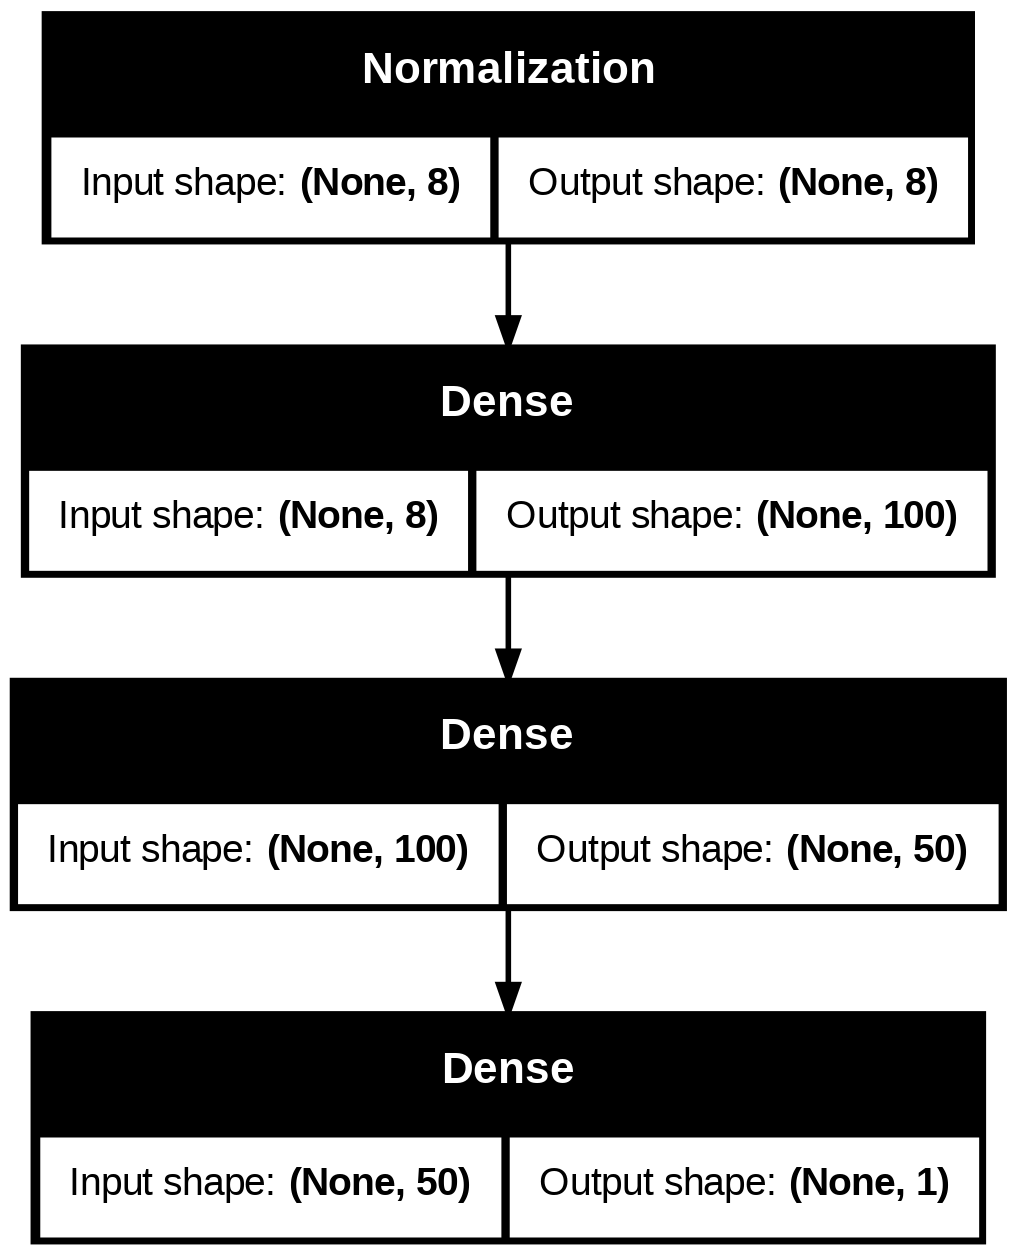

In [14]:
tf.keras.utils.plot_model(model, to_file="model.png",show_shapes=True)

In [25]:
model.compile(optimizer=Adam(learning_rate = 0.001),loss=MeanAbsoluteError(),metrics=[RootMeanSquaredError()])
history =model.fit(x_train,y_train,validation_data=(x_val,y_val),epochs=30,verbose =1)

Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - loss: 37209.5273 - root_mean_squared_error: 46397.6758 - val_loss: 39026.4258 - val_root_mean_squared_error: 48106.9844
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 35333.2969 - root_mean_squared_error: 44676.1328 - val_loss: 38997.8477 - val_root_mean_squared_error: 48098.7188
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 35343.7188 - root_mean_squared_error: 44862.3711 - val_loss: 39001.5039 - val_root_mean_squared_error: 48118.9180
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 37530.6602 - root_mean_squared_error: 46707.4531 - val_loss: 38969.0508 - val_root_mean_squared_error: 48085.3633
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 36643.9219 - root_mean_squared_error: 45996.0312 - val_loss: 39001.4844 - val_root_mean_squared_error: 48118.1094
Epoch 6/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 36640.5664 - root_mean_squared_error: 46120.2305 - val_loss: 39019.6797 - val_roo

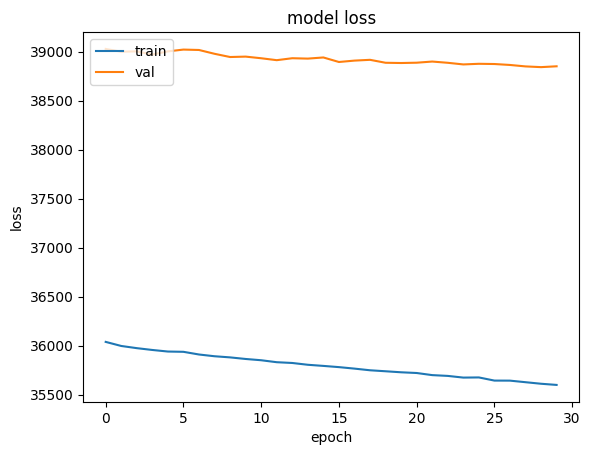

In [26]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [27]:
model.evaluate(x_test,y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 36967.0547 - root_mean_squared_error: 47207.0469 


[36493.1640625, 46343.57421875]

In [28]:
y_test[0]

<tf.Tensor: shape=(1,), dtype=float32, numpy=array([496293.5], dtype=float32)>

In [32]:
model.predict(tf.expand_dims(x_test[0],axis = 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


array([[531596.5]], dtype=float32)